# Project 4: Norfolk VA Mircomobility

**by: Lamiek Haile**

### Data Loading

In [1]:
# These lines are needed when exporting the notebook to html
import plotly.io as pio

pio.renderers.default = "notebook_connected"

# After all the cells have been run : 
#   jupyter nbconvert --to html matplotlib_plotly.ipynb
# needs to be entered into the terminal - make sure you are in the correct folder 

import sys
print(sys.executable)

/Library/Developer/CommandLineTools/usr/bin/python3


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv("Norfolk_scooter_bike.csv", low_memory=False)

### Data Inspection

In [3]:
df.head(3)
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999288 entries, 0 to 999287
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Trip ID                999288 non-null  object 
 1   Vehicle Type           999288 non-null  object 
 2   Trip Distance (miles)  999288 non-null  object 
 3   Starting Date          999288 non-null  object 
 4   Ending Date            999288 non-null  object 
 5   Maximum Temperature    985434 non-null  float64
 6   Minimum Temperature    985434 non-null  float64
 7   Precipitation          985434 non-null  float64
 8   Snow                   985434 non-null  float64
dtypes: float64(4), object(5)
memory usage: 68.6+ MB


Trip ID                      0
Vehicle Type                 0
Trip Distance (miles)        0
Starting Date                0
Ending Date                  0
Maximum Temperature      13854
Minimum Temperature      13854
Precipitation            13854
Snow                     13854
dtype: int64

This dataset contains micromobility trip data from Norfolk, VA in 2025. 
Each row represents a single trip with info including trip ID, vehicle type, trip distance, and start and end times. 
This also includes weather related variables but those variables have many null values. 
Several columns such as trip distance and the date columns are stored as strings and will need to be converted to appropriate data types.

### Data Cleaning and Filtering

#### Data Types

In [4]:
df['Trip Distance (miles)'] = df['Trip Distance (miles)'].astype(str).str.replace(",", "").astype(float)
df['Starting Date'] = pd.to_datetime(df['Starting Date'])
df['Ending Date'] = pd.to_datetime(df['Ending Date'])

#### Filtering

In [5]:
df['Trip Duration (min)'] = (df['Ending Date'] - df['Starting Date']).dt.total_seconds()/60



filtered_df = df[
    (df['Trip Duration (min)']> 0) & 
    (df['Trip Duration (min)'] < 100) & 
    (df['Trip Distance (miles)'] < 100)
].copy()

filtered_df['Month'] = filtered_df['Starting Date'].dt.month


### Questions and Answers

Question 1.
How the number of rentals changes over 2025?

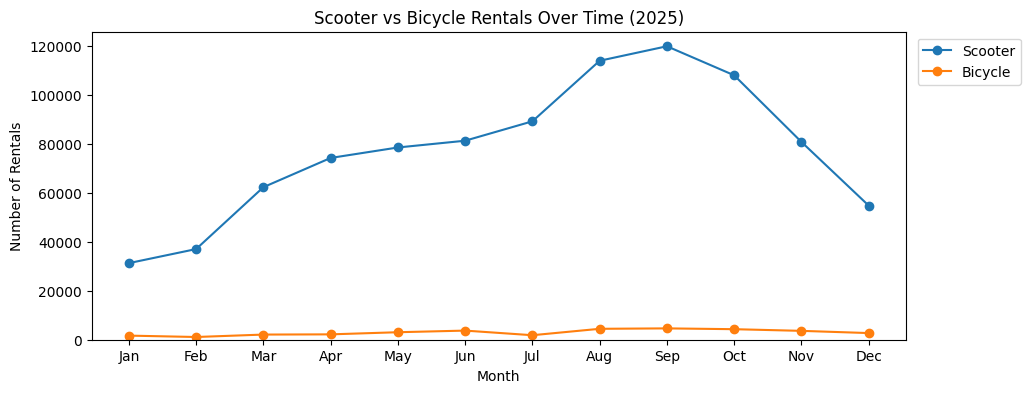

In [6]:
result = filtered_df.groupby(['Month','Vehicle Type']).agg({'Trip ID': 'count'}).unstack()
result = result['Trip ID']

plt.figure(figsize=(10.5, 4))

plt.plot(result.index, result['scooter'], marker='o', label='Scooter')
plt.plot(result.index, result['bicycle'], marker='o', label='Bicycle')

plt.xticks(
    ticks=result.index,
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)

plt.title('Scooter vs Bicycle Rentals Over Time (2025)')
plt.xlabel('Month')
plt.ylabel('Number of Rentals')

plt.ylim(bottom=0)

plt.legend(bbox_to_anchor=(1.15, 1))
plt.show()

In [7]:

fig = px.line(
    result,
    x=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    y=['scooter', 'bicycle'],
    markers=True,
    title='Scooter vs Bicycle Rentals Over Time (2025)'
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Number of Rentals',
    width = 1000,
    height = 400
)

fig.show()

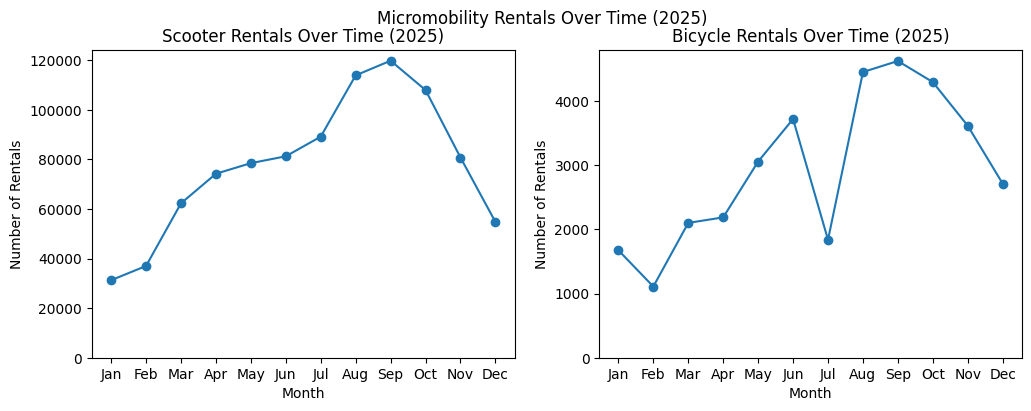

In [8]:
fig, axes = plt.subplots(1, 2,figsize=(12, 4))

axes[0].plot(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], result['scooter'], marker='o')
axes[0].set_title('Scooter Rentals Over Time (2025)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Rentals')
axes[0].set_ylim(bottom=0)

axes[1].plot(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], result['bicycle'], marker='o')
axes[1].set_title('Bicycle Rentals Over Time (2025)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Rentals')
axes[1].set_ylim(bottom=0)

plt.suptitle('Micromobility Rentals Over Time (2025)')

plt.show()

Rentals increase during the warmer months and decrease during the colder months. Scooters generally have higher usage than bicycles throughout the year. Both vehicle types follow similar seasonal patterns, with the highest rental activity occurring during the summer months.

Question 2.
What is the relationship between Precipitation and Trip Duration?

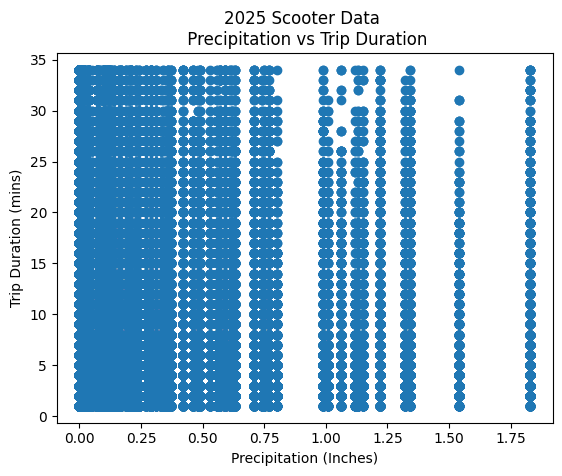

In [9]:
scooter_df = filtered_df[(filtered_df['Vehicle Type'] == 'scooter') &
                         (filtered_df['Trip Duration (min)'] < 35) &
                         (filtered_df['Precipitation'] < 2)]

x = scooter_df['Precipitation']
y = scooter_df['Trip Duration (min)']

plt.scatter(x,y)
plt.xlabel('Precipitation (Inches)')
plt.ylabel('Trip Duration (mins)')
plt.title('2025 Scooter Data \n Precipitation vs Trip Duration')

plt.show()

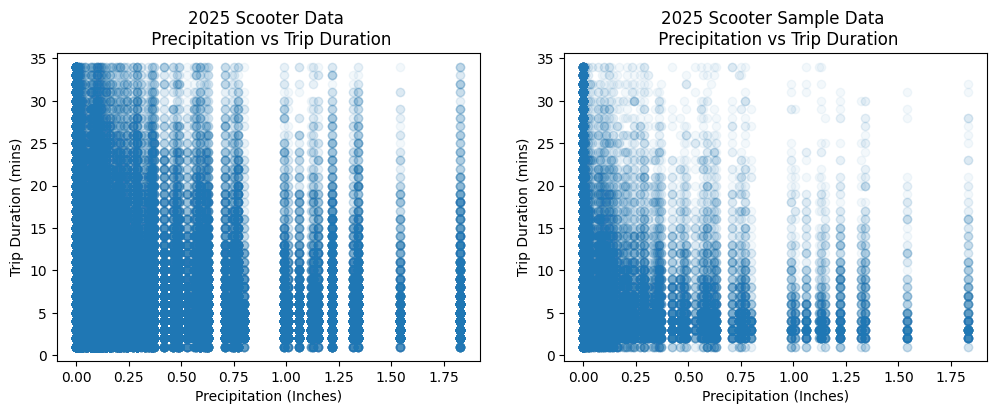

In [10]:
fig, axes = plt.subplots(1, 2,figsize=(12, 4))

axes[0].scatter(x,y,alpha=0.05)
axes[0].set_xlabel('Precipitation (Inches)')
axes[0].set_ylabel('Trip Duration (mins)')
axes[0].set_title('2025 Scooter Data \n Precipitation vs Trip Duration')

sample_df = scooter_df.sample(n=100000, random_state=1)
sample_x = sample_df['Precipitation']
sample_y = sample_df['Trip Duration (min)']


axes[1].scatter(sample_x, sample_y, alpha=0.05)
axes[1].set_xlabel('Precipitation (Inches)')
axes[1].set_ylabel('Trip Duration (mins)')
axes[1].set_title('2025 Scooter Sample Data \n Precipitation vs Trip Duration')


plt.show()

The scatter plots show that most scooter trips occur when precipitation is very low or close to zero. There does not appear to be a strong relationship between precipitation and trip duration, since the points remain widely spread across different trip lengths. However, as precipitation increases, the number of trips becomes much smaller, and longer trips appear less common. The transparent and sampled scatter plots make this pattern easier to see by reducing overplotting.

Question 3.
How are trip durations distributed for filtered micromobility trips in 2025?

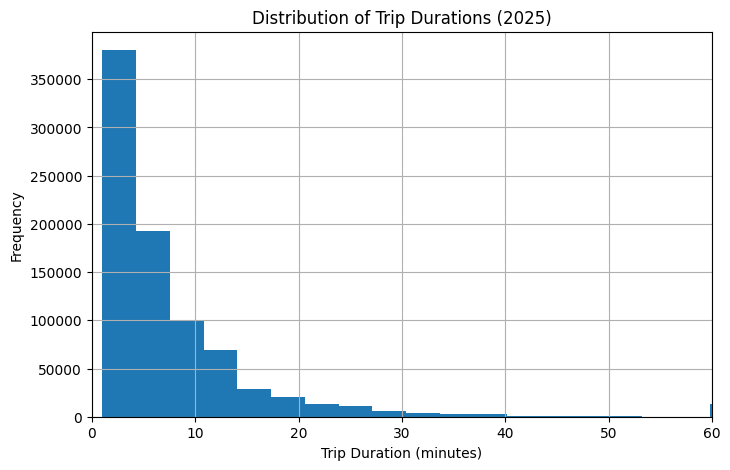

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(filtered_df['Trip Duration (min)'], bins=30)

plt.title('Distribution of Trip Durations (2025)')
plt.xlabel('Trip Duration (minutes)')
plt.xlim(0, 60)
plt.ylabel('Frequency')

plt.grid()

plt.show()

The histogram shows that most trips are short in duration, with many trips happening in the lower range of minutes. As the trip duration increases, the number of trips decreases. This means shorter trips are much more common, while longer trips happen less often.